# Ridge and Lasso Regression: A Comprehensive Guide

Ridge and Lasso are regularized versions of Linear Regression that add a penalty term to prevent overfitting. They are essential techniques when dealing with noisy data, multicollinearity, or high-dimensional datasets.

In this notebook, we'll cover:
1. Basic concepts of Ridge (L2) and Lasso (L1) regularization
2. Data preparation and visualization
3. Model implementation from scratch
4. Using scikit-learn for Ridge and Lasso
5. Model evaluation and comparison

# Simple Explanation: What Does the Code Below Do?

Regular Linear Regression tries to fit a line perfectly through all data points. But with noisy data, this can mean wild, extreme coefficients that perform badly on new data (overfitting).

Regularization adds a 'penalty' for large coefficients:
- **Ridge (L2)**: Penalty = α × Σ(wᵢ²) — shrinks all coefficients toward zero, but rarely to exactly zero.
- **Lasso (L1)**: Penalty = α × Σ|wᵢ| — can set coefficients exactly to zero (automatic feature selection!).
- **Elastic Net**: Combines both L1 and L2 penalties.

The **α (alpha)** parameter controls how much regularization:
- α = 0 → Regular Linear Regression (no regularization).
- α → ∞ → All coefficients forced to zero.

Here's what the code does:
1. Generates data with many features (some irrelevant).
2. Implements Ridge and Lasso from scratch.
3. Uses scikit-learn to compare models and tune alpha.
4. Shows how Lasso performs automatic feature selection.

In short: Regularization prevents overfitting by discouraging large, extreme model weights!

In [1]:
# Create a virtual environment and install required libraries
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed in the virtual environment.')
else:
    print('Could not find pip in the virtual environment. Please check your Python installation.')

Virtual environment already exists at ml_env
Required libraries installed in the virtual environment.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll create a regression dataset with many features (some informative, some noise/irrelevant).
This is where regularization shines!

Dataset shape: (200, 20)
Number of informative features: 5 out of 20
True non-zero coefficients: 5

True coefficient values (non-zero):
[48.50179875 51.80104314 61.41862443 97.246139    8.54030302]


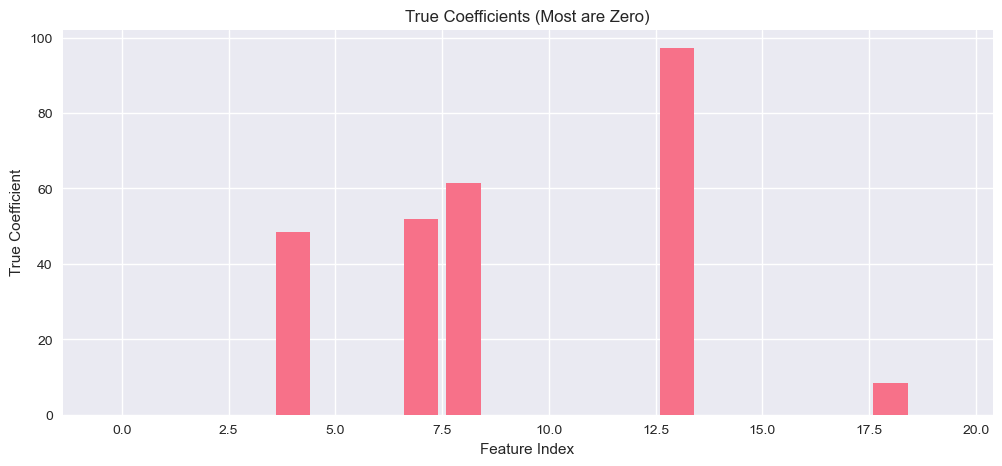

In [3]:
np.random.seed(42)

# Generate regression data: 20 features, only 5 are truly informative
X, y, true_coefs = make_regression(n_samples=200, n_features=20, n_informative=5, 
                                    noise=20, coef=True, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print('Dataset shape:', X.shape)
print(f'Number of informative features: 5 out of 20')
print(f'True non-zero coefficients: {np.sum(true_coefs != 0)}')
print('\nTrue coefficient values (non-zero):')
print(true_coefs[true_coefs != 0])

# Visualize true coefficients
plt.figure(figsize=(12, 5))
plt.bar(range(len(true_coefs)), true_coefs)
plt.xlabel('Feature Index')
plt.ylabel('True Coefficient')
plt.title('True Coefficients (Most are Zero)')
plt.grid(True, axis='y')
plt.show()

# 3. Implementing Ridge Regression from Scratch

Ridge minimizes: MSE + α × Σ(wᵢ²)

This has a closed-form solution: w = (XᵀX + αI)⁻¹ Xᵀy

Where α is the regularization strength (lambda).

In [4]:
class RidgeRegressionScratch:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Add bias term
        X_b = np.column_stack([np.ones(n_samples), X])
        # Ridge closed-form: (X'X + alphaI)^-1 X'y
        # Regularization doesn't apply to bias (first element)
        reg_matrix = self.alpha * np.eye(n_features + 1)
        reg_matrix[0, 0] = 0  # don't regularize the bias
        self.theta = np.linalg.inv(X_b.T @ X_b + reg_matrix) @ X_b.T @ y
        self.bias = self.theta[0]
        self.weights = self.theta[1:]

    def predict(self, X):
        return X @ self.weights + self.bias

# Compare OLS, Ridge (scratch), various alphas
alphas = [0.001, 0.1, 1.0, 10.0, 100.0]
print('=== Ridge vs OLS ===' )

# OLS (alpha=0)
ols = RidgeRegressionScratch(alpha=0.0001)
ols.fit(X_train, y_train)
ols_mse = mean_squared_error(y_test, ols.predict(X_test))
print(f'OLS (alpha≈0)   → Test MSE: {ols_mse:.2f}')

for alpha in alphas:
    ridge = RidgeRegressionScratch(alpha=alpha)
    ridge.fit(X_train, y_train)
    mse = mean_squared_error(y_test, ridge.predict(X_test))
    print(f'Ridge (α={alpha:6.3f}) → Test MSE: {mse:.2f}')

=== Ridge vs OLS ===
OLS (alpha≈0)   → Test MSE: 279.96
Ridge (α= 0.001) → Test MSE: 279.96
Ridge (α= 0.100) → Test MSE: 279.75
Ridge (α= 1.000) → Test MSE: 278.66
Ridge (α=10.000) → Test MSE: 340.93
Ridge (α=100.000) → Test MSE: 3244.53


# 4. Using Scikit-learn's Ridge, Lasso, and ElasticNet

Let's use scikit-learn's implementations, which automatically find the best alpha using cross-validation.

In [5]:
# RidgeCV: finds best alpha via cross-validation
alphas_to_try = np.logspace(-4, 4, 50)

ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_train, y_train)
print(f'Ridge CV - Best alpha: {ridge_cv.alpha_:.4f}')
print(f'Ridge CV - Test MSE: {mean_squared_error(y_test, ridge_cv.predict(X_test)):.2f}')
print(f'Ridge CV - Test R²:  {r2_score(y_test, ridge_cv.predict(X_test)):.4f}')

# LassoCV: finds best alpha via cross-validation
lasso_cv = LassoCV(alphas=alphas_to_try, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print(f'\nLasso CV - Best alpha: {lasso_cv.alpha_:.4f}')
print(f'Lasso CV - Test MSE: {mean_squared_error(y_test, lasso_cv.predict(X_test)):.2f}')
print(f'Lasso CV - Test R²:  {r2_score(y_test, lasso_cv.predict(X_test)):.4f}')
n_zero_lasso = np.sum(np.abs(lasso_cv.coef_) < 1e-6)
print(f'Lasso CV - Coefficients set to zero: {n_zero_lasso}/{X_train.shape[1]}')

# ElasticNet
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train, y_train)
print(f'\nElasticNet  - Test MSE: {mean_squared_error(y_test, elastic.predict(X_test)):.2f}')
print(f'ElasticNet  - Test R²:  {r2_score(y_test, elastic.predict(X_test)):.4f}')

Ridge CV - Best alpha: 1.7575
Ridge CV - Test MSE: 278.91
Ridge CV - Test R²:  0.9850

Lasso CV - Best alpha: 1.7575
Lasso CV - Test MSE: 257.36
Lasso CV - Test R²:  0.9862
Lasso CV - Coefficients set to zero: 12/20

ElasticNet  - Test MSE: 316.10
ElasticNet  - Test R²:  0.9830


# 5. Model Evaluation — Coefficient Comparison and Regularization Paths

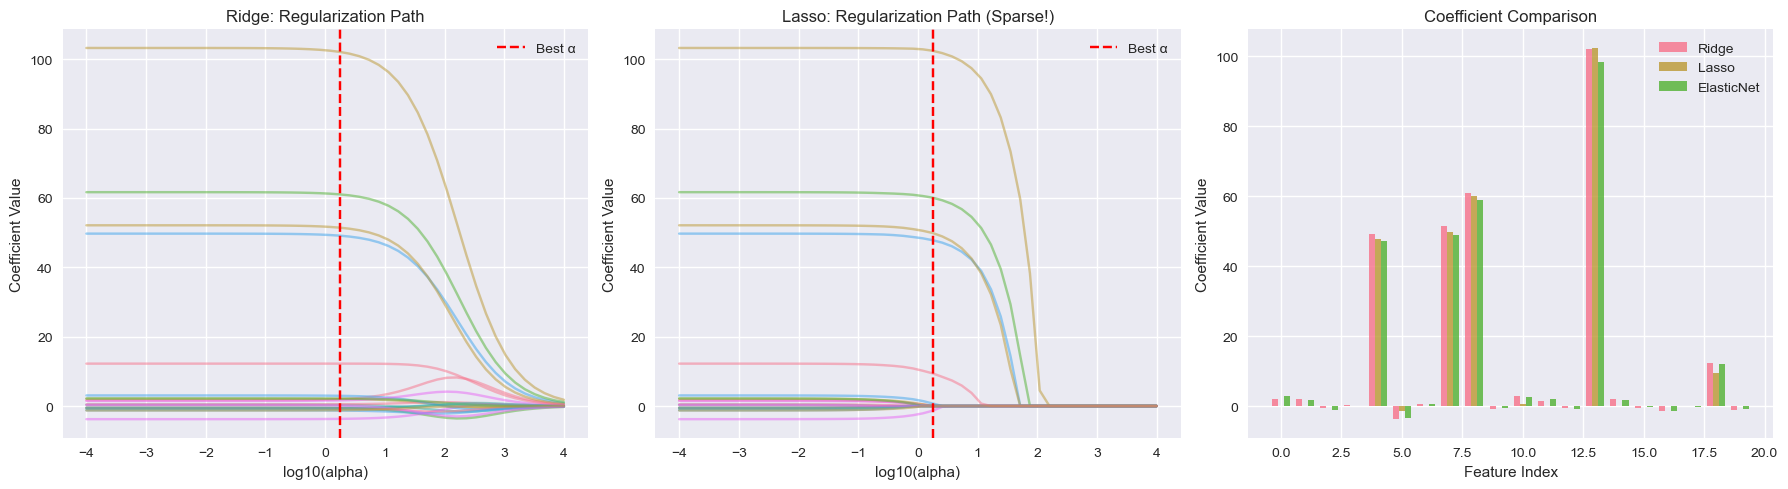


Key Insights:
- Ridge (L2): Shrinks all coefficients smoothly. Best when all features contribute.
- Lasso (L1): Can zero out coefficients → automatic feature selection!
- ElasticNet: Mix of both — handles groups of correlated features better.
- Use cross-validation (RidgeCV/LassoCV) to find the best alpha.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Ridge regularization path
coefs_ridge = []
for alpha in alphas_to_try:
    r = Ridge(alpha=alpha)
    r.fit(X_train, y_train)
    coefs_ridge.append(r.coef_)

coefs_ridge = np.array(coefs_ridge)
for i in range(X_train.shape[1]):
    axes[0].plot(np.log10(alphas_to_try), coefs_ridge[:, i], alpha=0.5)
axes[0].axvline(np.log10(ridge_cv.alpha_), color='red', linestyle='--', label=f'Best α')
axes[0].set_xlabel('log10(alpha)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge: Regularization Path')
axes[0].legend()

# 2. Lasso regularization path
coefs_lasso = []
for alpha in alphas_to_try:
    la = Lasso(alpha=alpha, max_iter=10000)
    la.fit(X_train, y_train)
    coefs_lasso.append(la.coef_)

coefs_lasso = np.array(coefs_lasso)
for i in range(X_train.shape[1]):
    axes[1].plot(np.log10(alphas_to_try), coefs_lasso[:, i], alpha=0.5)
axes[1].axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--', label=f'Best α')
axes[1].set_xlabel('log10(alpha)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso: Regularization Path (Sparse!)')
axes[1].legend()

# 3. Compare coefficients side by side
width = 0.25
indices = np.arange(X_train.shape[1])
axes[2].bar(indices - width, ridge_cv.coef_, width, label='Ridge', alpha=0.8)
axes[2].bar(indices, lasso_cv.coef_, width, label='Lasso', alpha=0.8)
axes[2].bar(indices + width, elastic.coef_, width, label='ElasticNet', alpha=0.8)
axes[2].set_xlabel('Feature Index')
axes[2].set_ylabel('Coefficient Value')
axes[2].set_title('Coefficient Comparison')
axes[2].legend()
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Ridge (L2): Shrinks all coefficients smoothly. Best when all features contribute.')
print('- Lasso (L1): Can zero out coefficients → automatic feature selection!')
print('- ElasticNet: Mix of both — handles groups of correlated features better.')
print('- Use cross-validation (RidgeCV/LassoCV) to find the best alpha.')

# Conclusions and Key Takeaways
Ridge and Lasso regression are the two fundamental regularization techniques applied to linear models to prevent overfitting, mathematically constraining the magnitude of the model's coefficients.
- **Ridge (L2)** shrinks all coefficients toward zero, reducing their impact, which is perfect for managing multicollinearity.
- **Lasso (L1)** has the unique geometric property of shrinking less important feature coefficients completely to absolute zero, thus performing built-in feature selection.

# Pros and Cons
**Pros:**
- Solves the problem of overfitting in standard Ordinary Least Squares (OLS) regression.
- Vital for datasets where the number of features exceeds the number of samples (p > n).
- Lasso delivers a highly readable, sparse model by actively dropping features.

**Cons:**
- Adds an extra hyperparameter (lambda/alpha) that must be rigorously tuned via Cross-Validation.
- Lasso struggles when features are highly correlated; it will arbitrarily select one and drop the rest, sacrificing information.
- They introduce a deliberate bias to the predictions to reduce variance, meaning predictions on training data will technically be "worse" than unregularized OLS.

# 15 Interview Questions and Answers

1. **What is the fundamental goal of Ridge and Lasso Regression?**
   *Answer*: To add a penalty to the loss function that constrains the size of the coefficients. This reduces the variance of the model at the cost of slight bias, preventing overfitting to the training data.

2. **What is the penalty term associated with Ridge Regression?**
   *Answer*: L2 Regularization. It adds a penalty equal to the sum of the squared magnitudes of the coefficients: Lambda * Σ(beta²).

3. **What is the penalty term associated with Lasso Regression?**
   *Answer*: L1 Regularization. It adds a penalty equal to the sum of the absolute values of the coefficients: Lambda * Σ|beta|.

4. **Why does Lasso result in sparse models (coefficients exactly zero) while Ridge doesn't?**
   *Answer*: It relates to the geometry of the optimization space. The L1 penalty forms a diamond shape with sharp corners on the axes. The gradient descent loss contour is highly likely to intersect the penalty space exactly on a corner, where a coefficient is zero. The L2 circle has no corners, so intersections almost never happen exactly on an axis.

5. **If two features are highly correlated, how do Ridge and Lasso handle them differently?**
   *Answer*: Ridge will distribute the coefficient weight roughly evenly between the two correlated features. Lasso is unstable in this scenario; it will arbitrarily pick one feature to keep the entire coefficient and shrink the other to absolute zero.

6. **What is Elastic Net?**
   *Answer*: A hybrid model that linearly combines the L1 and L2 penalties. It brings the feature selection property of Lasso while maintaining the stability of Ridge when dealing with highly correlated features.

7. **Why is it absolutely critical to standardize features before applying Ridge or Lasso?**
   *Answer*: Because the penalty is applied uniformly across all coefficients based on their magnitude. If variable A is measured in millions (tiny coefficient) and variable B is measured in fractions (large coefficient), variable B will be penalized vastly more simply because of its scale, which is incorrect.

8. **What happens as the regularization parameter (Lambda or alpha) approaches infinity?**
   *Answer*: The penalty completely dominates the optimization. The model shrinks all coefficients to exactly zero, resulting in a flat line representing just the intercept (highest possible bias, zero variance).

9. **What happens as the regularization parameter (Lambda or alpha) approaches zero?**
   *Answer*: The penalty term disappears. The problem reverts exactly to standard unregularized OLS Linear Regression.

10. **How do you choose the correct value for the regularization parameter?**
    *Answer*: Via K-Fold Cross-Validation. You test a grid or logarithmic scale of values (e.g., 0.001, 0.1, 1, 10, 100) and select the penalty strength that yields the lowest error on the validation folds.

11. **When is Ridge Regression better than ordinary Linear Regression?**
    *Answer*: When your dataset suffers from high multicollinearity, or when you have relatively few training samples but many features, putting the model at high risk of rapid overfitting.

12. **Can Ridge or Lasso be used for non-linear models?**
    *Answer*: Yes, indirect applications exist. For example, L1 and L2 penalties can be easily added to the cost function of Logistic Regression, Support Vector Machines, or Deep Neural Networks (often called Weight Decay).

13. **What does LASSO actually stand for?**
    *Answer*: Least Absolute Shrinkage and Selection Operator. 

14. **Why doesn't the intercept term get penalized in Ridge or Lasso?**
    *Answer*: Penalizing the intercept would mean forcing the decision boundary closer to the origin (0,0), which changes the model's fundamental ability to capture the simple mean of the target variable. Only the weights representing the relationship between features and the target should be constrained.

15. **Does Lasso Regression guarantee that it selects the "best" features?**
    *Answer*: No. It guarantees it will find a sparse set of features that minimizes the penalized loss function. In the presence of correlated predictors, the specific feature chosen by Lasso can be heavily influenced by random noise in the training set.
